In [250]:
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd


#Clustering imports
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

In [251]:
#check my executable b/c it's gotten mixed up with HBW in the past
import sys
print(sys.executable)

/opt/miniconda3/bin/python


In [252]:
# Reading in Ann Data Object: REMEMBER we are reading in bulk TPM normalize counts (Continous and Skewed Data) not discrete bulk, sc, or even spatial data
prad_path = "./GDCdata/seurat_se_tpm.h5ad"
prad_obj = sc.read_h5ad(prad_path)

In [253]:
# Filter for sample low counts genes per sample
sc.pp.filter_cells(prad_obj, min_genes=10)
sc.pp.filter_genes(prad_obj, min_cells=5)

#Already was normalized prior to read in but need log1p norm on TPM because of highly skewed data. (see R code summary)
sc.pp.log1p(prad_obj)

#Getting highly variable genes
sc.pp.highly_variable_genes(prad_obj, layer = "RNA_data", n_top_genes = 5000)

#storing hvg in anndata object
hvg = prad_obj[:, prad_obj.var["highly_variable"]].copy()

sc.pp.pca(hvg)

# PCA coordinates
hvg.obsm["X_pca_hvg"] = hvg.obsm["X_pca"].copy()
del hvg.obsm["X_pca"]
#loadings
hvg.varm["hvg_PCs"] = hvg.varm["PCs"].copy()
del hvg.varm["PCs"]
#metadata
hvg.uns["pca_hvg"] = hvg.uns["pca"].copy()
del hvg.uns["pca"]

In [254]:
hvg

AnnData object with n_obs × n_vars = 232 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'PATIENT_ID', 'SAMPLE_ID', 'age_at_diagnosis', 'race', 'gender', 'paper_PSA_preop', 'gleason_score', 'ajcc_pathologic_t', 'ajcc_pathologic_n', 'primary_diagnosis', 'paper_Residual_tumor', 'Subtype', 'paper_iCluster', 'paper_mRNA_cluster', 'paper_methylation_cluster', 'paper_ERG_status', 'paper_ETV1_status', 'paper_ETV4_status', 'paper_SPINK1_high', 'paper_FOXA1_mut', 'paper_SPOP_mut', 'paper_TP53_mut', 'paper_PTEN_mut', 'paper_Mutations', 'paper_Fraction_genome_altered', 'paper_ABSOLUTE_purity', 'paper_AR_score', 'vital_status', 'days_to_last_follow_up', 'cause_of_death', 'age_group', 'PSA_group', 'AR_score_group', 'ABSOLUTE_purity_group', 'FGA_group', 'n_genes'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'altExperiments', 'commands', 'version', 'log1p', 'hvg', 'pca_hvg'
    obsm: 'X_pca_hvg'
    varm: 'hvg_PCs'
    layers: 'RNA_counts', 'R

In [ ]:
# Summarizing here
# filter low counts genes
# log normalize TPM data to avoid the skewed nature
# Calculate for highly variable genes
# Store log(TPM + 1) HVGs mat into a seperate object
# Perform PCA on log(TPM + 1) HVGs
# renaming PCA objects

In [189]:
# TPM of TCGA-PRAD output
bulk_mat = prad_obj.X.toarray()
bulk_mat = pd.DataFrame(bulk_mat)
#colnames of the X
samples = prad_obj.obs_names
#rownames of X
genes = prad_obj.var_names
#highly_variable_features
hv_genes = hvg.var_names

## Kmeans Clustering of Transcriptomic Data

#### Silhouette_score Testing on Transcriptomic and PCA space

In [190]:
#silhouette_score explained:
#inter_cluster_cohesion = average distance to points in its own cluster = a
#intra_cluster_cohesion = average distance to points in the nearest other cluster = b
# b - a / max(a)

In [247]:
from scipy.sparse import issparse

#scalling data her
mat_scaled = StandardScaler().fit_transform(hvg.X.toarray())


range_n_clusters = list(range(2,7))
sil_avgs = []
#Testing for clustering using dense scaled HVG matrix
# Can the curated 232 sampless obe naturally divided into 2 though 7 groups based solely on expression (log TPM HVGs)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init = 10, random_state=42)
    #finding the centroids
    cluster_labels = kmeans.fit_predict(mat_scaled)
    silhouette_avg = silhouette_score(mat_scaled, cluster_labels)
    sil_avgs.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, average silhouette_score = {silhouette_avg:.3f}")

For n_clusters = 2, average silhouette_score = 0.754
For n_clusters = 3, average silhouette_score = 0.086
For n_clusters = 4, average silhouette_score = 0.091
For n_clusters = 5, average silhouette_score = 0.088
For n_clusters = 6, average silhouette_score = 0.063


In [257]:
# PCA of non log normalized TPM  values
pca_coords = hvg.obsm["X_pca_hvg"]

In [197]:
meta_vars = list(prad_obj.obs)
print(meta_vars)

['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'PATIENT_ID', 'SAMPLE_ID', 'age_at_diagnosis', 'race', 'gender', 'paper_PSA_preop', 'gleason_score', 'ajcc_pathologic_t', 'ajcc_pathologic_n', 'primary_diagnosis', 'paper_Residual_tumor', 'Subtype', 'paper_iCluster', 'paper_mRNA_cluster', 'paper_methylation_cluster', 'paper_ERG_status', 'paper_ETV1_status', 'paper_ETV4_status', 'paper_SPINK1_high', 'paper_FOXA1_mut', 'paper_SPOP_mut', 'paper_TP53_mut', 'paper_PTEN_mut', 'paper_Mutations', 'paper_Fraction_genome_altered', 'paper_ABSOLUTE_purity', 'paper_AR_score', 'vital_status', 'days_to_last_follow_up', 'cause_of_death', 'age_group', 'PSA_group', 'AR_score_group', 'ABSOLUTE_purity_group', 'FGA_group', 'n_genes']


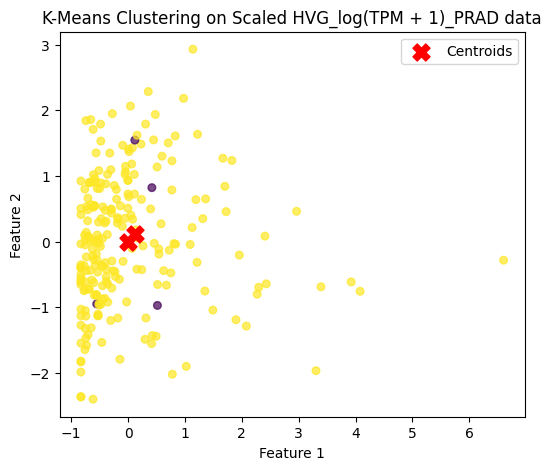

In [195]:
# Fit K-Means
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(mat_scaled)
y_pred = kmeans.predict(mat_scaled)
# y_pred = kmeans.fit_predict(X_blobs)

# Plot the results
plt.figure(figsize=(6, 5))
plt.scatter(mat_scaled[:, 0], mat_scaled[:, 1], c=y_pred, s=30, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", s=150, marker="X", label="Centroids")
plt.title("K-Means Clustering on Scaled HVG_log(TPM + 1)_PRAD data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


In [193]:
# Performing Sil Test using Clincial and Pathological Variables
#Central Question Does this label align with sturcture in GEX space

In [198]:
#filtering for targeted obs
clinical_vars = ['paper_PSA_preop', 'ajcc_pathologic_t', 'gleason_score']
binned_vars = ['PSA_group', 'AR_score_group', 'ABSOLUTE_purity_group', 'FGA_group', "Subtype"]
for obs in binned_vars:
    # accessessing meta vars obs
    labels = prad_obj.obs[obs]
    #masking for nas
    mask = labels.notna().to_numpy()

    meta_sil_score = silhouette_score(mat_scaled[mask],labels[mask])

    print(f"For meta_var = {obs}, average sil score = {meta_sil_score}")

for obs in clinical_vars:
    # accessessing meta vars obs
    labels = prad_obj.obs[obs]
    #masking for nas
    mask = labels.notna().to_numpy()

    meta_sil_score = silhouette_score(mat_scaled[mask],labels[mask])

    print(f"For meta_var = {obs}, average sil score = {meta_sil_score} ")

For meta_var = PSA_group, average sil score = -0.07278067618608475
For meta_var = AR_score_group, average sil score = -0.0413346067070961
For meta_var = ABSOLUTE_purity_group, average sil score = 0.009726195596158504
For meta_var = FGA_group, average sil score = 0.006157787516713142
For meta_var = Subtype, average sil score = -0.08314789086580276
For meta_var = paper_PSA_preop, average sil score = -0.16323749721050262 
For meta_var = ajcc_pathologic_t, average sil score = -0.17526783049106598 
For meta_var = gleason_score, average sil score = -0.029654301702976227 


In [200]:
# PCA of non log normalized TPM  values
prad_obj.obsm[""]

array([[ -5.65479305, -76.12069266,  15.37211164, ...,   0.29846575,
         -0.23872906,   2.67447019],
       [ -6.31605726,  18.2279801 ,   4.23742595, ...,  -2.01020942,
         -0.66671373,   0.60388822],
       [ -3.04065337,  20.54559837,  -2.60909656, ...,  -0.49276077,
         -5.08901013,  -3.26838331],
       ...,
       [ -1.77692471,  29.80271459,   4.24048523, ...,  -3.22372175,
          2.48116202,   7.48640631],
       [ -4.13181294,  15.49612756,   6.80852308, ...,   3.76768441,
          1.98465166,  -1.059342  ],
       [ -4.23441658, -29.49324231,   9.72647358, ...,   2.27607835,
         -1.89121563,   3.91997557]], shape=(232, 50))

In [ ]:
pca_data = 

In [ ]:
# Tested with High Sil score on scaled HVGs of log(TPM + 1) GEX data
# Results Summary
# Result: Found that centroids are essentially stacked on top. Even if those outliers were deleted it would not change the terrible clustering.
# Overall we see weak intrinsic clustering structure of HVG GEX space alone.
# Looking below this would extent further to clinical and pathological variables as well
# sil scores are all at or below 0 
# Which shows that any potential clustering method within HVG GEX space would be worse if based on clinical or pathological vars using Kmeans.
#However, That does not mean that TPM GEX is non-clusterable: Kmeans assumes spherical clusters
# K-Means uses simple straight-line distance (Euclidean distance).
#This makes it work best when clusters are roughly circular (in 2D) or spherical (in higher dimensions) and have similar sizes.
#It struggles with elongated, curved, or unevenly sized clusters.
#Since out data is naturally continuous, Kmeans is a bad fit because we are forcing it in bordered clusters.